# Часть 1

## Генератор стилей

In [2]:
import sys

sys.path.append("/kaggle/input/datasets/lastrige/itmo-gen1")

In [4]:
import numpy as np
from styles import styles, styles_count

In [7]:
def generate_style():
    category_probs = {}
    for category, counts in styles_count.items():
        total = sum(counts)
        if total > 0:
            category_probs[category] = {}
            for style, count in zip(styles[category], counts):
                category_probs[category][style] = count / total
    
    total_styles = sum(len(styles_list) for styles_list in styles.values())
    style_probabilities = {}
    
    for category, styles_list in styles.items():
        for style in styles_list:
            category_prob = len(styles_list) / total_styles
            style_prob = category_probs[category].get(style, 0) * category_prob
            style_probabilities[style] = style_prob
    
    total_prob = sum(style_probabilities.values())
    if total_prob > 0:
        for style in style_probabilities:
            style_probabilities[style] /= total_prob
    
    selected_styles = {}
    total_probability = 1.0
    
    for category, styles_list in styles.items():
        probs = [category_probs[category].get(style, 0) for style in styles_list]
        if np.sum(probs) > 0:
            probs = np.array(probs) / np.sum(probs)
        else:
            probs = np.ones(len(styles_list)) / len(styles_list)
        selected_style = np.random.choice(styles_list, p=probs)
        style_prob = category_probs[category].get(selected_style, 0)
        selected_styles[category] = selected_style
        total_probability *= style_prob if style_prob > 0 else 1.0 / len(styles_list)
    
    return selected_styles, total_probability


def generate_multiple_styles(n=5):
    results = []
    for i in range(n):
        styles_dict, probability = generate_style()
        results.append((styles_dict, probability))
        print(f"Пример {i+1}:")
        print(f"Вероятность: {probability}")
        for category, style in styles_dict.items():
            print(f"    {category}: {style}")
        print()
    
    return results

### Примеры стилей

In [8]:
generate_multiple_styles(5)

Пример 1:
Вероятность: 0.001703
    прическа: нет волос
    цвет волос: серебристо серый
    аксесуар: круглые очки
    одежда: комбинезон
    цвет одежды: розовый

Пример 2:
Вероятность: 0.001316
    прическа: короткая курчавые
    цвет волос: серебристо серый
    аксесуар: солнцезащитные очки
    одежда: комбинезон
    цвет одежды: розовый

Пример 3:
Вероятность: 0.001399
    прическа: длинные прямые
    цвет волос: серебристо серый
    аксесуар: круглые очки
    одежда: футболка с V-вырезом
    цвет одежды: белый

Пример 4:
Вероятность: 0.003243
    прическа: длинные прямые
    цвет волос: серебристо серый
    аксесуар: солнцезащитные очки
    одежда: комбинезон
    цвет одежды: серый

Пример 5:
Вероятность: 0.000373
    прическа: короткая курчавые
    цвет волос: черный
    аксесуар: круглые очки
    одежда: комбинезон
    цвет одежды: серый



[({'прическа': np.str_('нет волос'),
   'цвет волос': np.str_('серебристо серый'),
   'аксесуар': np.str_('круглые очки'),
   'одежда': np.str_('комбинезон'),
   'цвет одежды': np.str_('розовый')},
  0.0017031168000000002),
 ({'прическа': np.str_('короткая курчавые'),
   'цвет волос': np.str_('серебристо серый'),
   'аксесуар': np.str_('солнцезащитные очки'),
   'одежда': np.str_('комбинезон'),
   'цвет одежды': np.str_('розовый')},
  0.0013160448000000002),
 ({'прическа': np.str_('длинные прямые'),
   'цвет волос': np.str_('серебристо серый'),
   'аксесуар': np.str_('круглые очки'),
   'одежда': np.str_('футболка с V-вырезом'),
   'цвет одежды': np.str_('белый')},
  0.0013989888),
 ({'прическа': np.str_('длинные прямые'),
   'цвет волос': np.str_('серебристо серый'),
   'аксесуар': np.str_('солнцезащитные очки'),
   'одежда': np.str_('комбинезон'),
   'цвет одежды': np.str_('серый')},
  0.0032431103999999997),
 ({'прическа': np.str_('короткая курчавые'),
   'цвет волос': np.str_('черн

## Генератор аватаров

In [14]:
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
AVATARS_DIR = "/kaggle/input/datasets/lastrige/itmo-gen1/avatars"
IMG_SIZE = (64, 64)

In [19]:
def load_pixels(folder):
    paths = list(Path(folder).glob("*.png")) + list(Path(folder).glob("*.jpg"))
    arrays = []
    for path in paths:
        img = Image.open(path).convert("RGB").resize(IMG_SIZE)
        arrays.append(np.array(img, dtype=np.float32))
        
    return np.stack(arrays)

def mle_probs(data):
    H, W, C = data.shape[1], data.shape[2], data.shape[3]
    probs = np.zeros((H, W, C, 256), dtype=np.float64)
    for img in data:
        for c in range(C):
            for i in range(H):
                for j in range(W):
                    probs[i, j, c, int(img[i, j, c])] += 1
    probs /= len(data)
    
    return probs

def avatar_gen(folder=AVATARS_DIR):
    data = load_pixels(folder)
    probs = mle_probs(data)
    H, W, C = probs.shape[:3]
    vals = np.arange(256)
    while True:
        img = np.zeros((H, W, C), dtype=np.uint8)
        log_prob = 0.0
        for c in range(C):
            for i in range(H):
                for j in range(W):
                    p = probs[i, j, c]
                    p = p / p.sum()
                    v = np.random.choice(vals, p=p)
                    img[i, j, c] = v
                    log_prob += np.log(p[v] + 1e-12)
                    
        yield Image.fromarray(img, "RGB"), log_prob

/tmp/ipykernel_58/990287047.py:39: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  yield Image.fromarray(img, "RGB"), log_prob


avatar_1.png  log P = -13185.518884867113
avatar_2.png  log P = -13157.600867471654
avatar_3.png  log P = -13239.862291676238
avatar_4.png  log P = -13211.442813933076
avatar_5.png  log P = -13223.574525585924


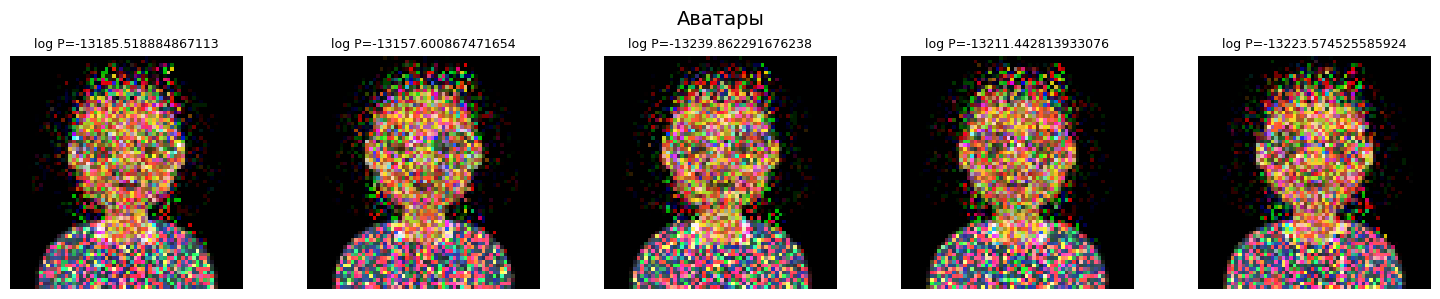

In [20]:
gen = avatar_gen()
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Аватары', fontsize=14)
avatars = []
log_probs = []
for k in range(5):
    img, log_prob = next(gen)
    avatars.append(img)
    log_probs.append(log_prob)
    print(f"avatar_{k+1}.png  log P = {log_prob}")
    
for i, (img, log_prob) in enumerate(zip(avatars, log_probs)):
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'log P={log_prob}', fontsize=9)
plt.tight_layout()
plt.show()

# Часть 2

### Первый подход - свертки, трешхолд как аргмакс tpr - fpr

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 1e-3
DATA_DIR = '/kaggle/input/datasets/lastrige/itmo-gen1/dataset/dataset'

Используется устройство: cuda


In [13]:
class ImageFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

class TestDataset(Dataset):
    def __init__(self, img_dir, annotation_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.samples = []
        
        with open(annotation_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    filename, label = parts
                else:
                    parts = line.strip().split(',')
                    filename, label = parts[0], parts[1]
                
                self.samples.append((os.path.join(img_dir, filename), int(label)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()])

train_dataset = ImageFolderDataset(os.path.join(DATA_DIR, 'train'), transform)
proliv_dataset = ImageFolderDataset(os.path.join(DATA_DIR, 'proliv'), transform)
test_dataset = TestDataset(
    os.path.join(DATA_DIR, 'test', 'imgs'), 
    os.path.join(DATA_DIR, 'test', 'test_annotation.txt'), 
    transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
proliv_loader = DataLoader(proliv_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)}, Proliv: {len(proliv_dataset)}, Test: {len(test_dataset)}")

Train: 10000, Proliv: 154, Test: 3794


In [14]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU(), nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1), nn.ReLU(), nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 3, kernel_size=3, padding=1), nn.Sigmoid(), nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = ConvAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Upsample(scale_factor=2.0, mode='bilinear')
    (3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Upsample(scale_factor=2.0, mode='bilinear')
    (6): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
    (8): Upsample(scal

Epoch [5/30], Loss: 0.000301
Epoch [10/30], Loss: 0.000227
Epoch [15/30], Loss: 0.000198
Epoch [20/30], Loss: 0.000196
Epoch [25/30], Loss: 0.000186
Epoch [30/30], Loss: 0.000178


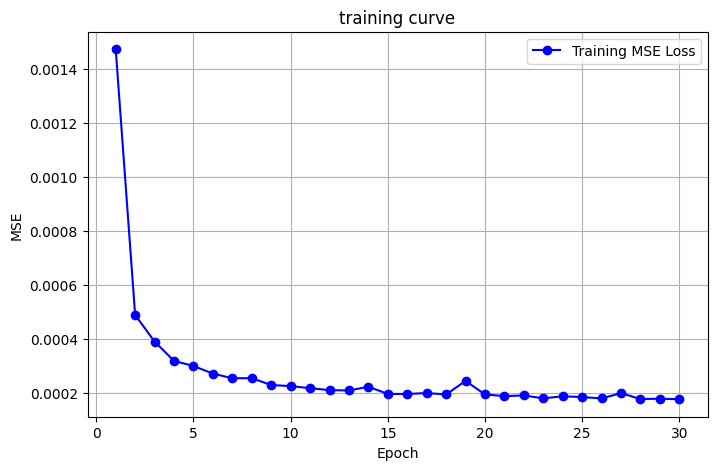

In [15]:
train_losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for data in train_loader:
        img = data.to(device)
        
        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, img)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * img.size(0)
        
    avg_loss = epoch_loss / len(train_dataset)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Training MSE Loss', color='b', marker='o')
plt.title('training curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
def calculate_mse(model, dataloader):
    model.eval()
    mses = []
    with torch.no_grad():
        for data in dataloader:
            if isinstance(data, list):
                img = data[0].to(device)
            else:
                img = data.to(device)
                
            output = model(img)
            mse = ((img - output) ** 2).mean(dim=(1, 2, 3)).cpu().numpy()
            mses.extend(mse)
    return np.array(mses)

train_mse = calculate_mse(model, train_loader)
proliv_mse = calculate_mse(model, proliv_loader)

y_true = np.concatenate([np.zeros_like(train_mse), np.ones_like(proliv_mse)])
y_scores = np.concatenate([train_mse, proliv_mse])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
diff = tpr - fpr
optimal_idx = np.argmax(diff)
optimal_threshold = thresholds[optimal_idx]

print(f"Оптимальный порог MSE: {optimal_threshold:.6f}")

Оптимальный порог MSE: 0.000405


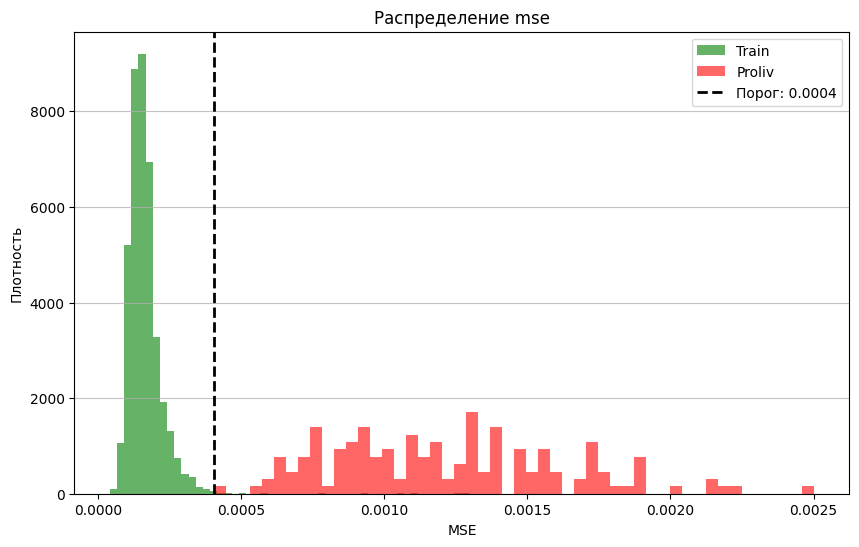

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(train_mse, bins=50, alpha=0.6, color='green', label='Train', density=True)
plt.hist(proliv_mse, bins=50, alpha=0.6, color='red', label='Proliv', density=True)

plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Порог: {optimal_threshold:.4f}')

plt.title('Распределение mse')
plt.xlabel('MSE')
plt.ylabel('Плотность')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Реконструкция нормальных изображений (Train):


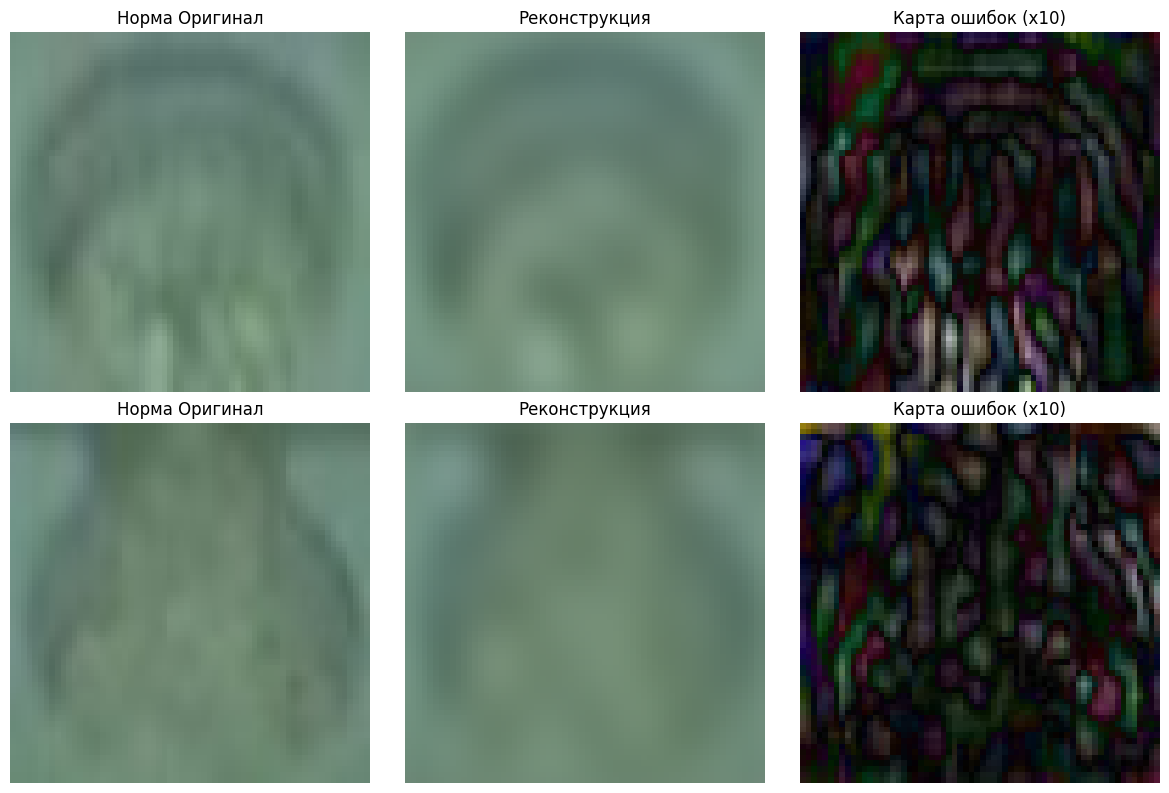


Реконструкция изображений с проливом (Proliv):


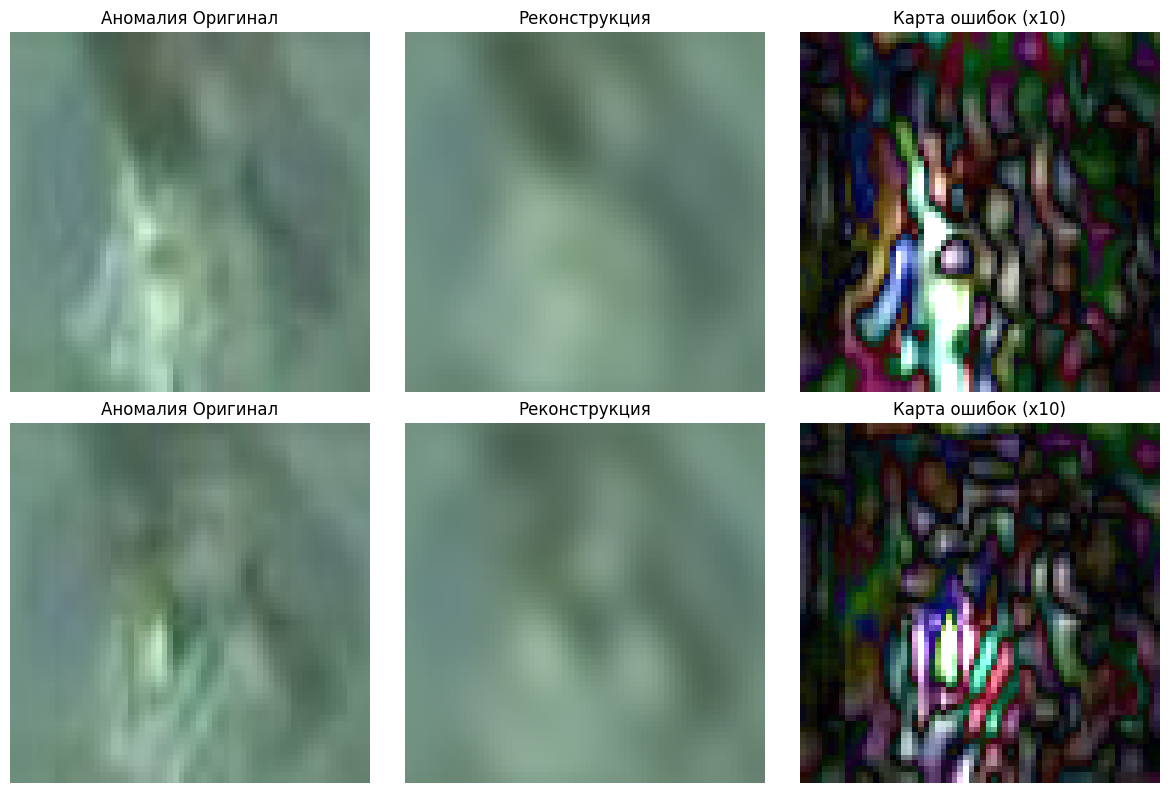

In [18]:
def show_reconstructions(model, dataloader, num_images=2, title_prefix=""):
    model.eval()
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    if num_images == 1:
        axes = axes.reshape(1, -1)
        
    with torch.no_grad():
        for i, data in enumerate(dataloader):
            if i >= num_images:
                break
            img = data[0].to(device) if isinstance(data, tuple) else data.to(device)
            output = model(img)
            
            img_np = img.cpu().permute(0, 2, 3, 1).numpy()
            out_np = output.cpu().permute(0, 2, 3, 1).numpy()
            diff_np = np.abs(img_np - out_np)
            diff_np = np.clip(diff_np * 10, 0, 1) 
            
            axes[i, 0].imshow(img_np[0])
            axes[i, 0].set_title(f'{title_prefix} Оригинал')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(out_np[0])
            axes[i, 1].set_title('Реконструкция')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(diff_np[0], cmap='hot')
            axes[i, 2].set_title('Карта ошибок (x10)')
            axes[i, 2].axis('off')
            
    plt.tight_layout()
    plt.show()

print("Реконструкция нормальных изображений (Train):")
show_reconstructions(model, train_loader, num_images=2, title_prefix="Норма")

print("\nРеконструкция изображений с проливом (Proliv):")
show_reconstructions(model, proliv_loader, num_images=2, title_prefix="Аномалия")

--- Результаты на тестовой выборке ---
True Positive Rate (TPR / Recall): 0.7984 (79.84%)
True Negative Rate (TNR / Specificity): 0.8196 (81.96%)

Отчет классификации:
               precision    recall  f1-score   support

Не пролив (0)       0.99      0.82      0.90      3665
   Пролив (1)       0.13      0.80      0.23       129

     accuracy                           0.82      3794
    macro avg       0.56      0.81      0.56      3794
 weighted avg       0.96      0.82      0.87      3794



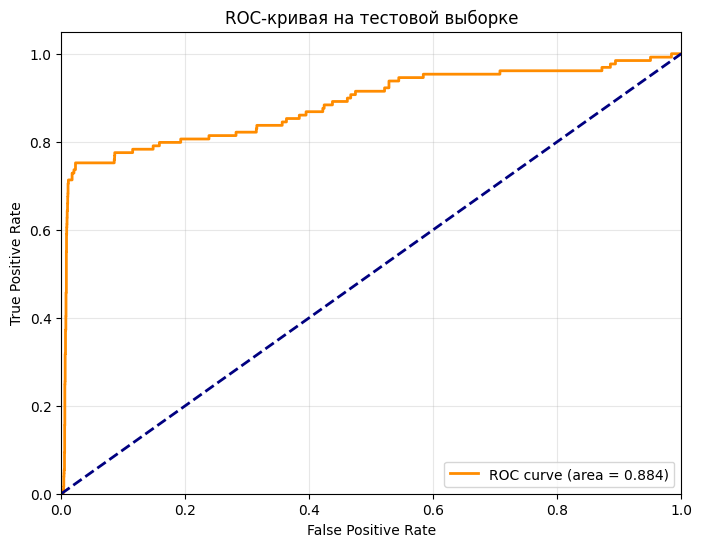

In [25]:
test_mse = calculate_mse(model, test_loader)

y_test_true = np.array([label for _, label in test_dataset.samples])

y_test_pred = (test_mse > optimal_threshold).astype(int)

if np.mean(y_test_pred == y_test_true) < 0.5:
    y_test_pred = 1 - y_test_pred

tn, fp, fn, tp = confusion_matrix(y_test_true, y_test_pred).ravel()

tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0

print("--- Результаты на тестовой выборке ---")
print(f"True Positive Rate (TPR / Recall): {tpr:.4f} ({tpr*100:.2f}%)")
print(f"True Negative Rate (TNR / Specificity): {tnr:.4f} ({tnr*100:.2f}%)")
print("\nОтчет классификации:")
print(classification_report(y_test_true, y_test_pred, target_names=['Не пролив (0)', 'Пролив (1)']))

fpr_test, tpr_test, _ = roc_curve(y_test_true, test_mse)
roc_auc = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая на тестовой выборке')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Второй подход - base + BN + dropout

In [26]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()])

train_dataset = ImageFolderDataset(os.path.join(DATA_DIR, 'train'), transform)
proliv_dataset = ImageFolderDataset(os.path.join(DATA_DIR, 'proliv'), transform)
test_dataset = TestDataset(
    os.path.join(DATA_DIR, 'test', 'imgs'), 
    os.path.join(DATA_DIR, 'test', 'test_annotation.txt'), 
    transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
proliv_loader = DataLoader(proliv_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)}, Proliv: {len(proliv_dataset)}, Test: {len(test_dataset)}")

Train: 10000, Proliv: 154, Test: 3794


In [31]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3)
        )
        
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = ConvAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.3, inplace=False)
  )
  (decoder): Sequential(
    (0):

In [32]:
def calculate_mse(model, dataloader):
    model.eval()
    mses = []
    with torch.no_grad():
        for data in dataloader:
            if isinstance(data, list):
                img = data[0].to(device)
            else:
                img = data.to(device)
                
            output = model(img)
            mse = ((img - output) ** 2).mean(dim=(1, 2, 3)).cpu().numpy()
            mses.extend(mse)
    return np.array(mses)

Epoch [5/30], Loss: 0.000215
Epoch [10/30], Loss: 0.000168
Epoch [15/30], Loss: 0.000144
Epoch [20/30], Loss: 0.000147
Epoch [25/30], Loss: 0.000134
Epoch [30/30], Loss: 0.000138


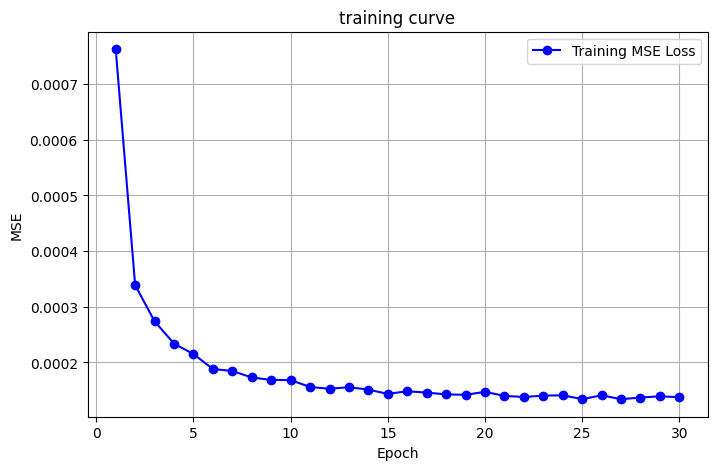

In [34]:
train_losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for data in train_loader:
        img = data.to(device)
        
        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, img)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * img.size(0)
        
    avg_loss = epoch_loss / len(train_dataset)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Training MSE Loss', color='b', marker='o')
plt.title('training curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(True)
plt.legend()
plt.show()

In [35]:
train_mse = calculate_mse(model, train_loader)
proliv_mse = calculate_mse(model, proliv_loader)

y_true = np.concatenate([np.zeros_like(train_mse), np.ones_like(proliv_mse)])
y_scores = np.concatenate([train_mse, proliv_mse])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
diff = tpr - fpr
optimal_idx = np.argmax(diff)
optimal_threshold = thresholds[optimal_idx]

print(f"Оптимальный порог MSE: {optimal_threshold:.6f}")

Оптимальный порог MSE: 0.000411


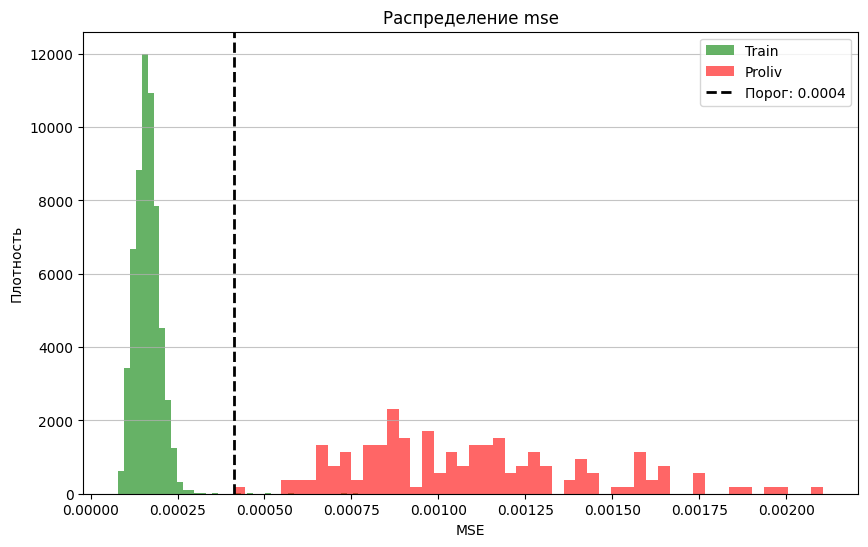

In [36]:
plt.figure(figsize=(10, 6))

plt.hist(train_mse, bins=50, alpha=0.6, color='green', label='Train', density=True)
plt.hist(proliv_mse, bins=50, alpha=0.6, color='red', label='Proliv', density=True)

plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Порог: {optimal_threshold:.4f}')

plt.title('Распределение mse')
plt.xlabel('MSE')
plt.ylabel('Плотность')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Реконструкция нормальных изображений (Train):


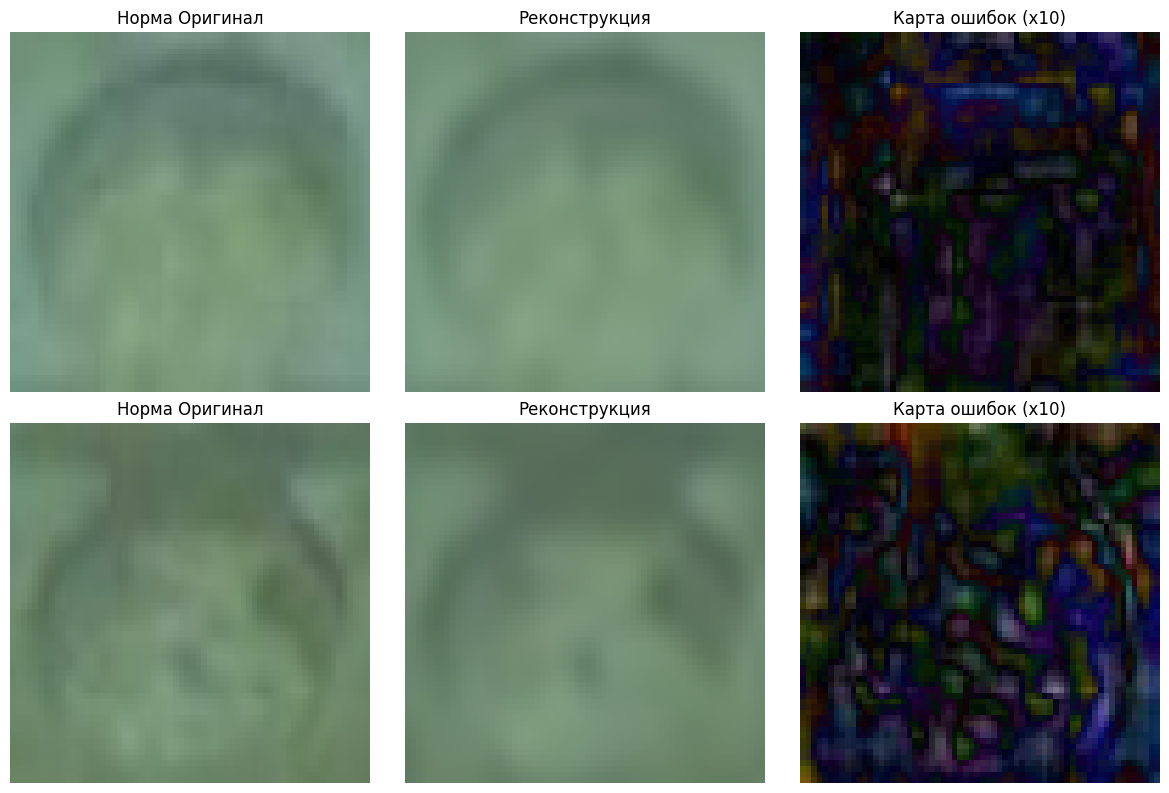


Реконструкция изображений с проливом (Proliv):


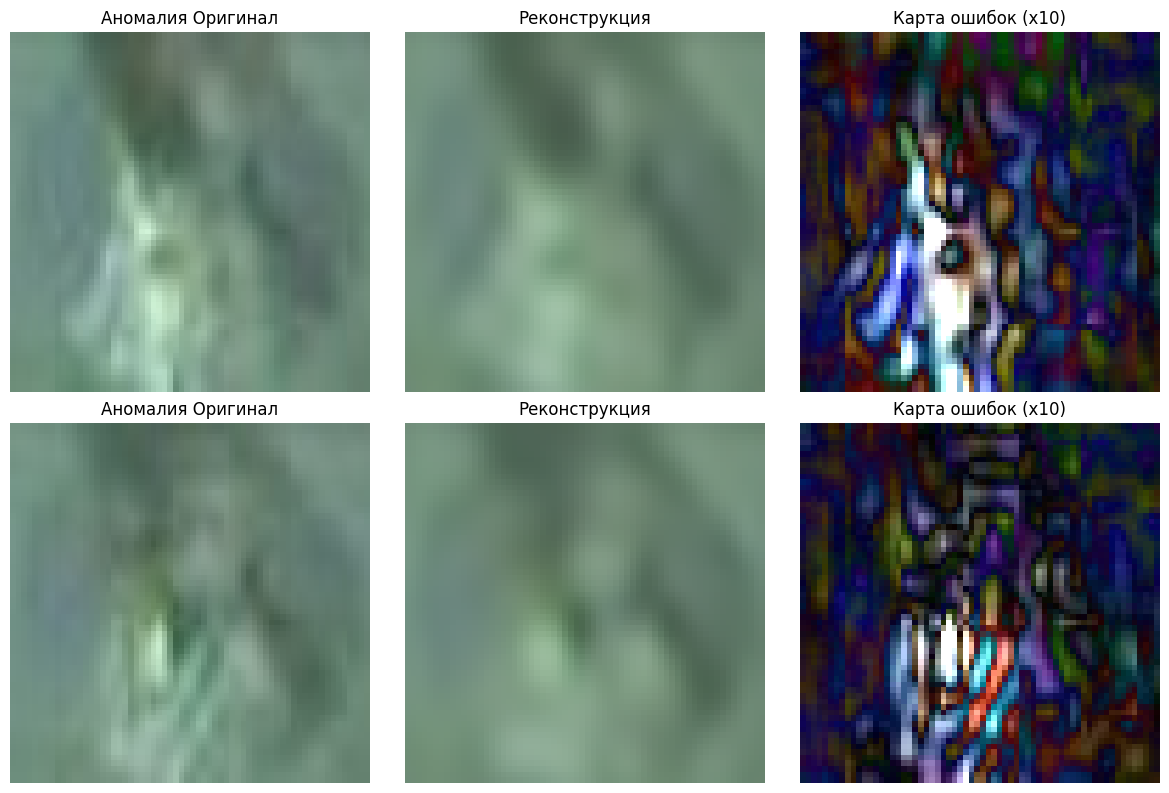

In [37]:
def show_reconstructions(model, dataloader, num_images=2, title_prefix=""):
    model.eval()
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    if num_images == 1:
        axes = axes.reshape(1, -1)
        
    with torch.no_grad():
        for i, data in enumerate(dataloader):
            if i >= num_images:
                break
            img = data[0].to(device) if isinstance(data, tuple) else data.to(device)
            output = model(img)
            
            img_np = img.cpu().permute(0, 2, 3, 1).numpy()
            out_np = output.cpu().permute(0, 2, 3, 1).numpy()
            diff_np = np.abs(img_np - out_np)
            diff_np = np.clip(diff_np * 10, 0, 1) 
            
            axes[i, 0].imshow(img_np[0])
            axes[i, 0].set_title(f'{title_prefix} Оригинал')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(out_np[0])
            axes[i, 1].set_title('Реконструкция')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(diff_np[0], cmap='hot')
            axes[i, 2].set_title('Карта ошибок (x10)')
            axes[i, 2].axis('off')
            
    plt.tight_layout()
    plt.show()

print("Реконструкция нормальных изображений (Train):")
show_reconstructions(model, train_loader, num_images=2, title_prefix="Норма")

print("\nРеконструкция изображений с проливом (Proliv):")
show_reconstructions(model, proliv_loader, num_images=2, title_prefix="Аномалия")

--- Результаты на тестовой выборке ---
True Positive Rate (TPR / Recall): 0.7907 (79.07%)
True Negative Rate (TNR / Specificity): 0.8936 (89.36%)

Отчет классификации:
               precision    recall  f1-score   support

Не пролив (0)       0.99      0.89      0.94      3665
   Пролив (1)       0.21      0.79      0.33       129

     accuracy                           0.89      3794
    macro avg       0.60      0.84      0.63      3794
 weighted avg       0.97      0.89      0.92      3794



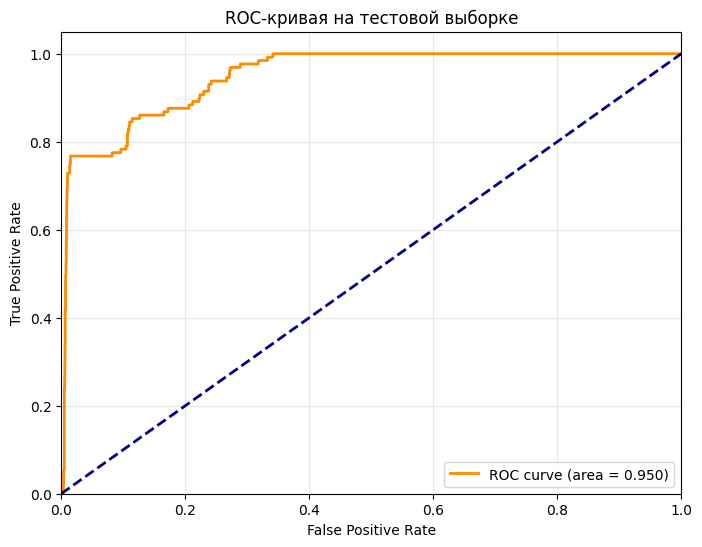

In [38]:
test_mse = calculate_mse(model, test_loader)
y_test_true = np.array([label for _, label in test_dataset.samples])

y_test_pred = (test_mse > optimal_threshold).astype(int)
if np.mean(y_test_pred == y_test_true) < 0.5:
    y_test_pred = 1 - y_test_pred

tn, fp, fn, tp = confusion_matrix(y_test_true, y_test_pred).ravel()

tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0

print("--- Результаты на тестовой выборке ---")
print(f"True Positive Rate (TPR / Recall): {tpr:.4f} ({tpr*100:.2f}%)")
print(f"True Negative Rate (TNR / Specificity): {tnr:.4f} ({tnr*100:.2f}%)")
print("\nОтчет классификации:")
print(classification_report(y_test_true, y_test_pred, target_names=['Не пролив (0)', 'Пролив (1)']))

fpr_test, tpr_test, _ = roc_curve(y_test_true, test_mse)
roc_auc = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая на тестовой выборке')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Третий подход - оставляем только 1 канал

In [68]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()])

train_dataset = ImageFolderDataset(os.path.join(DATA_DIR, 'train'), transform)
proliv_dataset = ImageFolderDataset(os.path.join(DATA_DIR, 'proliv'), transform)
test_dataset = TestDataset(
    os.path.join(DATA_DIR, 'test', 'imgs'), 
    os.path.join(DATA_DIR, 'test', 'test_annotation.txt'), 
    transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
proliv_loader = DataLoader(proliv_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)}, Proliv: {len(proliv_dataset)}, Test: {len(test_dataset)}")

Train: 10000, Proliv: 154, Test: 3794


In [75]:
class ConvAutoencoderV2(nn.Module):
    def __init__(self):
        super(ConvAutoencoderV2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = ConvAutoencoderV2().to(device)

criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print("Обновленная модель (Grayscale, L1 Loss, Dropout):")
print(model)

Обновленная модель (Grayscale, L1 Loss, Dropout):
ConvAutoencoderV2(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Upsample(scale_factor=2.0, mode='bilinear')
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Upsample(scale_factor=2.0, mode='bilinear')
    (6): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding

Epoch [5/30], Loss: 0.000241
Epoch [10/30], Loss: 0.000191
Epoch [15/30], Loss: 0.000178
Epoch [20/30], Loss: 0.000159
Epoch [25/30], Loss: 0.000154
Epoch [30/30], Loss: 0.000151


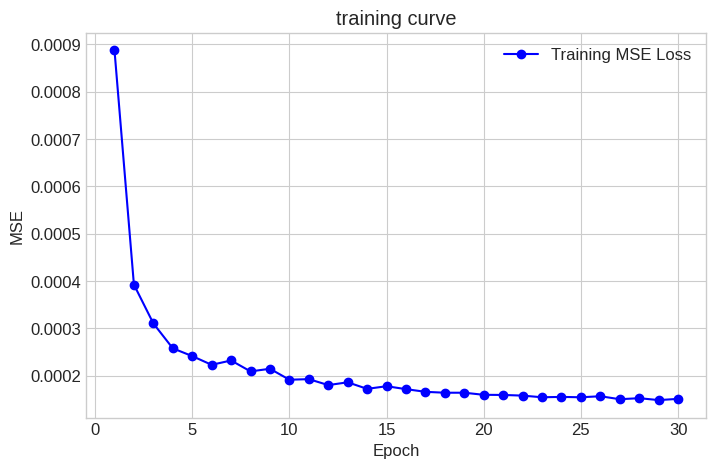

In [76]:
train_losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for data in train_loader:
        img = data.to(device)
        
        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, img)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * img.size(0)
        
    avg_loss = epoch_loss / len(train_dataset)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Training MSE Loss', color='b', marker='o')
plt.title('training curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(True)
plt.legend()
plt.show()

In [81]:
train_mse = calculate_mse(model, train_loader)
proliv_mse = calculate_mse(model, proliv_loader)

y_true = np.concatenate([np.zeros_like(train_mse), np.ones_like(proliv_mse)])
y_scores = np.concatenate([train_mse, proliv_mse])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
diff = tpr - fpr
optimal_idx = np.argmax(diff)
optimal_threshold = thresholds[optimal_idx]

print(f"Оптимальный порог MSE: {optimal_threshold:.6f}")

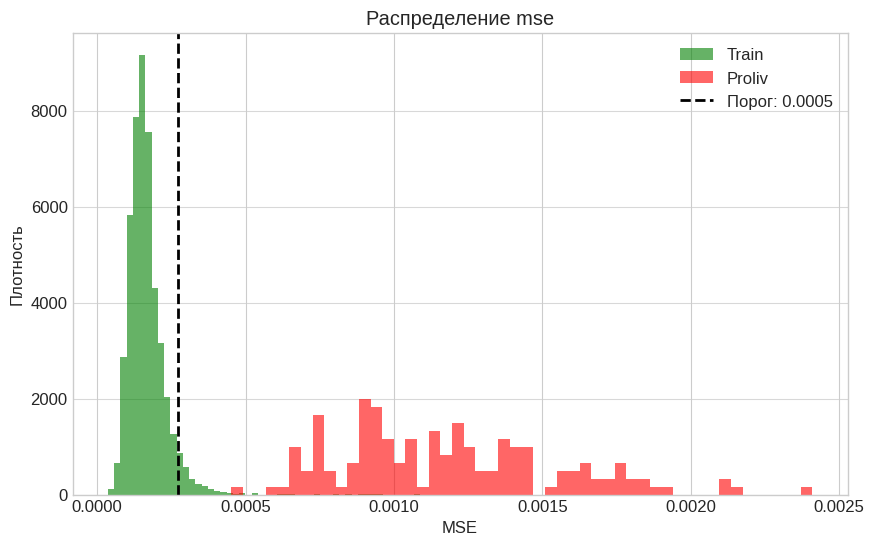

In [82]:
plt.figure(figsize=(10, 6))

plt.hist(train_mse, bins=50, alpha=0.6, color='green', label='Train', density=True)
plt.hist(proliv_mse, bins=50, alpha=0.6, color='red', label='Proliv', density=True)

plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Порог: {optimal_threshold:.4f}')

plt.title('Распределение mse')
plt.xlabel('MSE')
plt.ylabel('Плотность')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Реконструкция нормальных изображений (Train):


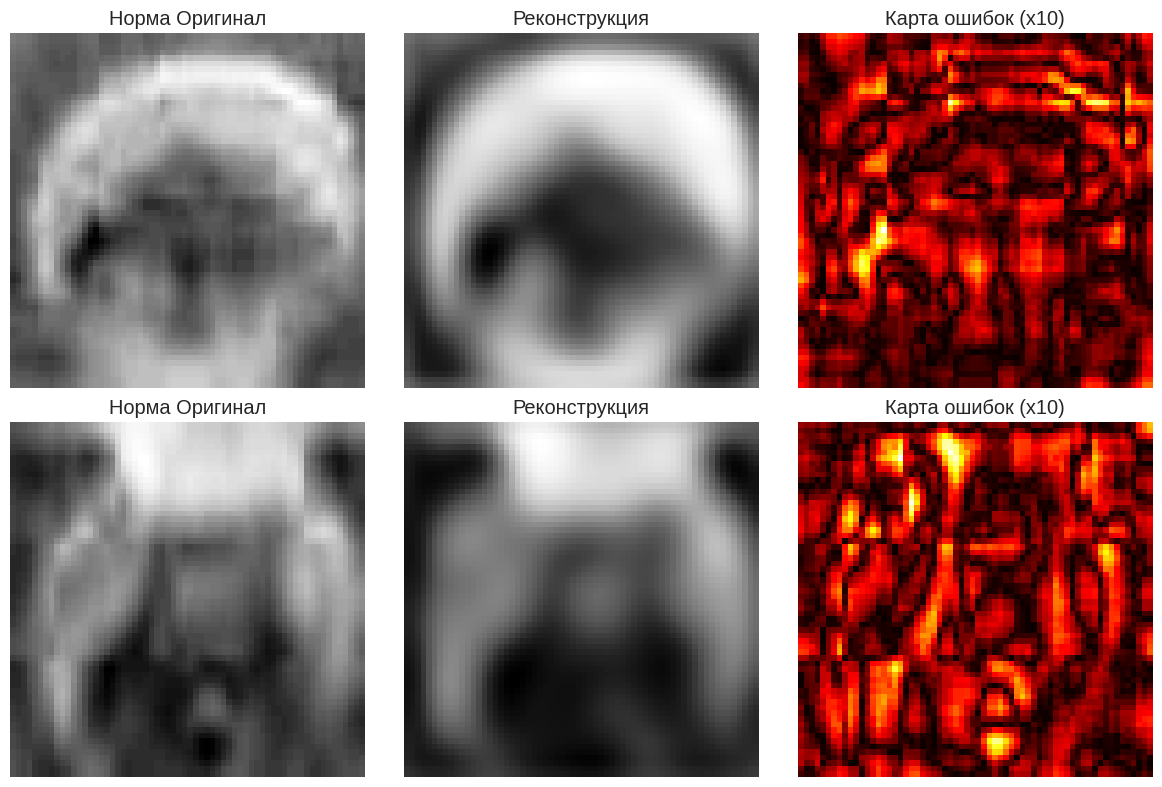


Реконструкция изображений с проливом (Proliv):


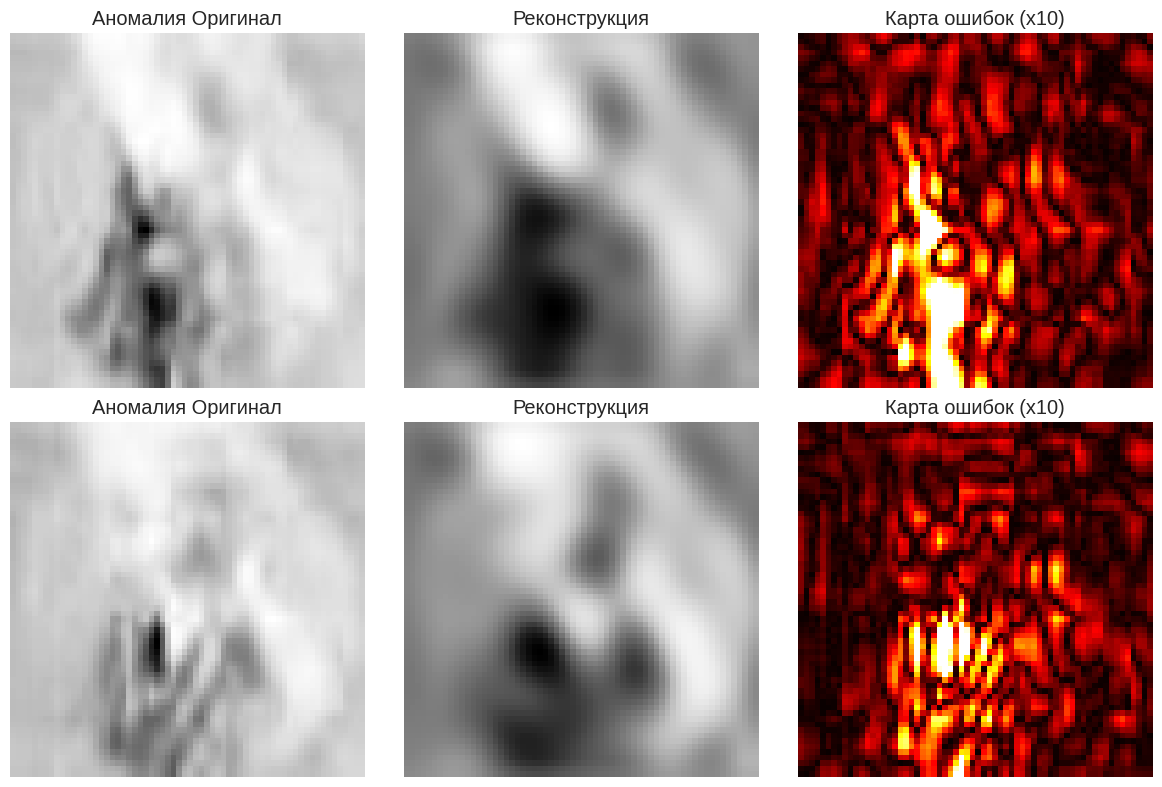

In [79]:
def show_reconstructions(model, dataloader, num_images=2, title_prefix=""):
    model.eval()
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    if num_images == 1:
        axes = axes.reshape(1, -1)
        
    with torch.no_grad():
        for i, data in enumerate(dataloader):
            if i >= num_images:
                break
            img = data[0].to(device) if isinstance(data, tuple) else data.to(device)
            output = model(img)
            
            img_np = img.cpu().permute(0, 2, 3, 1).numpy()
            out_np = output.cpu().permute(0, 2, 3, 1).numpy()
            diff_np = np.abs(img_np - out_np)
            diff_np = np.clip(diff_np * 10, 0, 1) 
            
            axes[i, 0].imshow(img_np[0])
            axes[i, 0].set_title(f'{title_prefix} Оригинал')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(out_np[0])
            axes[i, 1].set_title('Реконструкция')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(diff_np[0], cmap='hot')
            axes[i, 2].set_title('Карта ошибок (x10)')
            axes[i, 2].axis('off')
            
    plt.tight_layout()
    plt.show()

print("Реконструкция train:")
show_reconstructions(model, train_loader, num_images=2, title_prefix="Норма")

print("\nРеконструкция proliv:")
show_reconstructions(model, proliv_loader, num_images=2, title_prefix="Пролив")

--- Результаты на тестовой выборке ---
True Positive Rate (TPR / Recall): 0.8062 (80.62%)
True Negative Rate (TNR / Specificity): 0.6128 (61.28%)

Отчет классификации:
               precision    recall  f1-score   support

Не пролив (0)       0.99      0.61      0.76      3665
   Пролив (1)       0.07      0.81      0.13       129

     accuracy                           0.62      3794
    macro avg       0.53      0.71      0.44      3794
 weighted avg       0.96      0.62      0.74      3794



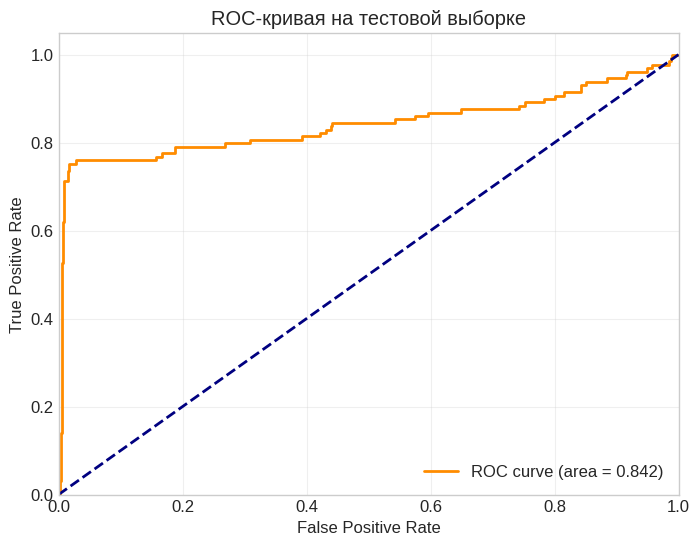

In [83]:
test_mse = calculate_mse(model, test_loader)

y_test_true = np.array([label for _, label in test_dataset.samples])

y_test_pred = (test_mse > optimal_threshold).astype(int)

if np.mean(y_test_pred == y_test_true) < 0.5:
    y_test_pred = 1 - y_test_pred

tn, fp, fn, tp = confusion_matrix(y_test_true, y_test_pred).ravel()

tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0

print("--- Результаты на тестовой выборке ---")
print(f"True Positive Rate (TPR / Recall): {tpr:.4f} ({tpr*100:.2f}%)")
print(f"True Negative Rate (TNR / Specificity): {tnr:.4f} ({tnr*100:.2f}%)")
print("\nОтчет классификации:")
print(classification_report(y_test_true, y_test_pred, target_names=['Не пролив (0)', 'Пролив (1)']))

fpr_test, tpr_test, _ = roc_curve(y_test_true, test_mse)
roc_auc = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая на тестовой выборке')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()